In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import (classification_report, recall_score, PrecisionRecallDisplay, confusion_matrix, average_precision_score, 
                             precision_recall_curve, roc_auc_score, cohen_kappa_score)

## Data Preparation

In [2]:
# =====================
# 1. Prepare Data
# =====================
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df.head(2)

X = df.drop(columns=['status'])
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# print("Before SMOTE:", Counter(y_train))
# print("After SMOTE:", Counter(y_train_sm))

## Base Model

In [3]:
# =====================
# 2. Base Random Forest Model (SMOTE outside pipeline)
# =====================
base_rf = RandomForestClassifier(random_state=42)
base_rf.fit(X_train_sm, y_train_sm)

y_pred_base = base_rf.predict(X_test)
y_proba_base = base_rf.predict_proba(X_test)[:, 1]
y_train_pred_base = base_rf.predict(X_train_sm)

print(confusion_matrix(y_test, y_pred_base))
print('------------------------------------------------------')
print(classification_report(y_test, y_pred_base, digits=3))
print('------------------------------------------------------')
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_base):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_base):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_base):.3f}")
print(f"Training recall: {recall_score(y_train_sm, y_train_pred_base):.3f}")

[[519 188]
 [205 399]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.717     0.734     0.725       707
           1      0.680     0.661     0.670       604

    accuracy                          0.700      1311
   macro avg      0.698     0.697     0.698      1311
weighted avg      0.700     0.700     0.700      1311

------------------------------------------------------
Test Avg Precision: 0.746
Test AUC: 0.764
Test Cohen's Kappa: 0.395
Training recall: 0.992


## Tuned Model

In [4]:
# =====================
# 3. Tuned Random Forest using Pipeline + GridSearchCV
# =====================
pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2],
    'rf__max_features': ['sqrt', 'log2', None]
}

grid_rf = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='recall',
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42),
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)  # SMOTE is handled in pipeline

best_rf = grid_rf.best_estimator_
y_pred_tune = best_rf.predict(X_test)
y_proba_tune = best_rf.predict_proba(X_test)[:, 1]
y_train_pred_tuned = best_rf.predict(X_train)

print("Best Parameters:", grid_rf.best_params_)
print('------------------------------------------------------')
print(confusion_matrix(y_test, y_pred_tune))
print('------------------------------------------------------')
print(classification_report(y_test, y_pred_tune, digits=3))
print('------------------------------------------------------')
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_tune):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_tune):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_tune):.3f}")
print(f"Training recall: {recall_score(y_train, y_train_pred_tuned):.3f}")

Fitting 15 folds for each of 72 candidates, totalling 1080 fits
Best Parameters: {'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
------------------------------------------------------
[[481 226]
 [161 443]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.749     0.680     0.713       707
           1      0.662     0.733     0.696       604

    accuracy                          0.705      1311
   macro avg      0.706     0.707     0.705      1311
weighted avg      0.709     0.705     0.705      1311

------------------------------------------------------
Test Avg Precision: 0.770
Test AUC: 0.785
Test Cohen's Kappa: 0.411
Training recall: 0.796


### 95% CI on Recall

Recall 95% CI: (0.699, 0.765)


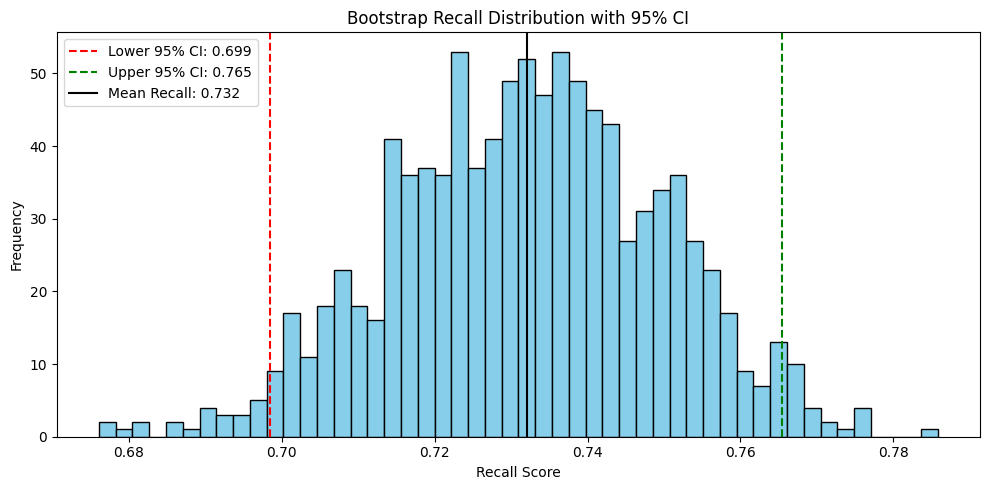

In [5]:
# Bootstrap
def bootstrap_ci_recall_distribution(y_true, y_pred_func, X, n_bootstraps=1000, alpha=0.95):
    rng = np.random.RandomState(42)
    bootstrapped_scores = []
    n = len(y_true)
    for _ in range(n_bootstraps):
        indices = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true.iloc[indices])) < 2:
            continue
        score = recall_score(y_true.iloc[indices], y_pred_func(X.iloc[indices]))
        bootstrapped_scores.append(score)
    sorted_scores = np.sort(bootstrapped_scores)
    lower = np.percentile(sorted_scores, ((1-alpha)/2)*100)
    upper = np.percentile(sorted_scores, (alpha + (1-alpha)/2)*100)
    return bootstrapped_scores, lower, upper

# scores
recall_scores, lower_ci, upper_ci = bootstrap_ci_recall_distribution(
    y_test.reset_index(drop=True), 
    best_rf.predict, 
    X_test.reset_index(drop=True)
)

print(f"Recall 95% CI: ({lower_ci:.3f}, {upper_ci:.3f})")

# plot
plt.figure(figsize=(10, 5))
plt.hist(recall_scores, bins=50, color='skyblue', edgecolor='black')
plt.axvline(lower_ci, color='red', linestyle='--', label=f"Lower 95% CI: {lower_ci:.3f}")
plt.axvline(upper_ci, color='green', linestyle='--', label=f"Upper 95% CI: {upper_ci:.3f}")
plt.axvline(np.mean(recall_scores), color='black', linestyle='-', label=f"Mean Recall: {np.mean(recall_scores):.3f}")
plt.title("Bootstrap Recall Distribution with 95% CI")
plt.xlabel("Recall Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance

             Feature  Base Model  Tuned Model
1       child weight    0.466245     0.444604
0          child age    0.144155     0.177763
8       wealth index    0.095832     0.087171
6   mother education    0.072883     0.085715
5          child sex    0.039147     0.030105
4               area    0.027954     0.026573
10           karnali    0.013199     0.022827
12           madhesh    0.016566     0.021983
3              fever    0.031242     0.021307
9            gandaki    0.013949     0.018353
2          diarrhoea    0.019307     0.014216
11             koshi    0.016588     0.014111
14     sudurpashchim    0.014719     0.013654
13           lumbini    0.017468     0.011331
7   health insurance    0.010745     0.010287


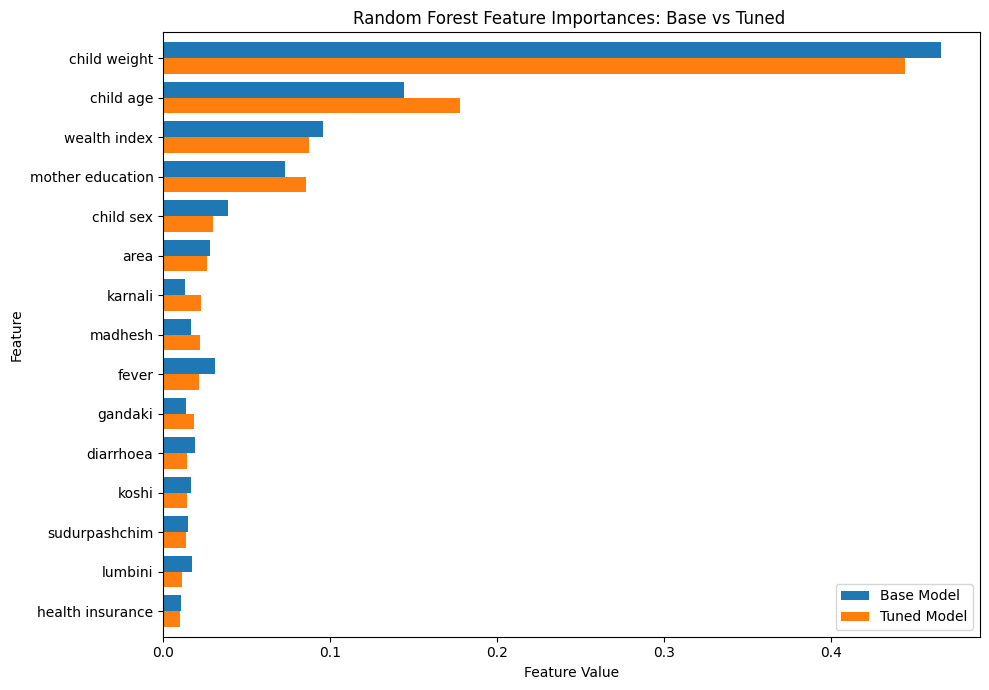

In [10]:
# Get feature names
feature_names = X.columns

# Extract the Random Forest model from the pipeline
rf_tuned_model = best_rf.named_steps['rf']  # from pipeline
rf_base_model = base_rf  # directly used without pipeline

# Get feature importances
importances_base = rf_base_model.feature_importances_
importances_tuned = rf_tuned_model.feature_importances_

# Combine into DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Base Model': importances_base,
    'Tuned Model': importances_tuned
}).sort_values(by='Tuned Model', ascending=False)

print(importance_df)

# Plot
top_features = importance_df.set_index('Feature')

top_features.plot(kind='barh', figsize=(10, 7), width = 0.8)
plt.title('Random Forest Feature Importances: Base vs Tuned ')
plt.xlabel('Feature Value')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
# plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


### Average Precision Plot

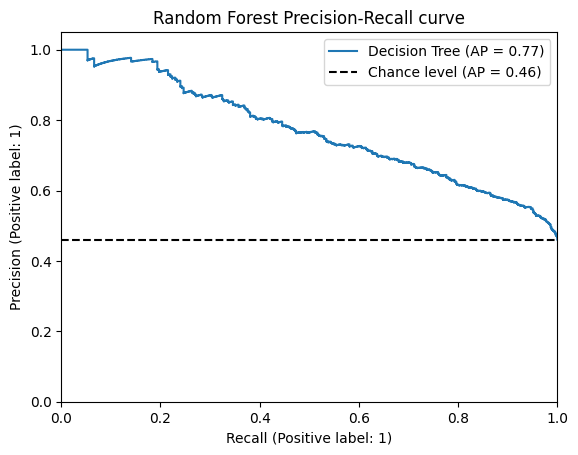

In [7]:
display = PrecisionRecallDisplay.from_estimator(
    best_rf,            # Trained model
    X_test,              # Test features
    y_test,              # True labels
    name="Decision Tree",          # Name for legend
    plot_chance_level=True  # Automatically plots chance-level baseline
)

display.ax_.set_title("Random Forest Precision-Recall curve")
display.ax_.legend(loc='upper right')
display.ax_.set_xlim([0.0, 1.0])
display.ax_.set_ylim([0.0, 1.05])
plt.show()

### 

## Additional

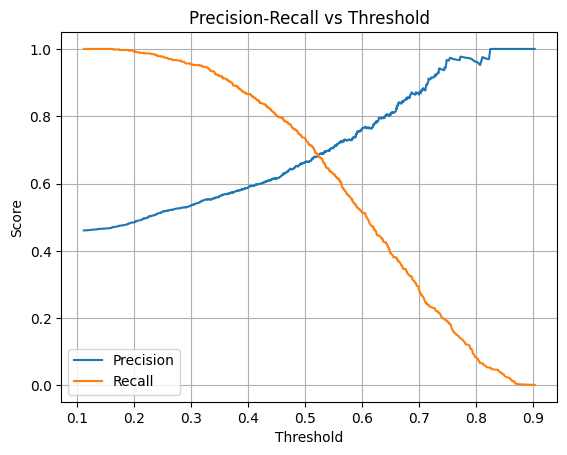

In [8]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_tune)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [9]:
# Apply custom threshold
y_probas_custom = (y_proba_tune >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.81      0.48      0.61       707
           1       0.59      0.87      0.70       604

    accuracy                           0.66      1311
   macro avg       0.70      0.67      0.65      1311
weighted avg       0.71      0.66      0.65      1311


